# Exchange Rate Forecasting — Machine Learning and LSTM

This notebook evaluates Random Forest, XGBoost and LSTM models for EUR/USD forecasting and applies the XGBoost pipeline to the other currency pairs. The chronological train/test split from the original project is preserved.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

DATA_DIR = Path("../data")
master_monthly = pd.read_csv(DATA_DIR / "processed_monthly_exchange_data.csv", parse_dates=["Date"])

train_size = int(len(master_monthly) * 0.8)

X = master_monthly[["DXY", "Brent_Oil", "Fed_Funds", "CPI", "Trade_Balance"]]
y = master_monthly["EURUSD"]

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 153
Test size: 39


## 1. Random Forest

In [2]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
mae_rf = mean_absolute_error(y_test, rf_predictions)
mape_rf = np.mean(np.abs((y_test - rf_predictions) / y_test)) * 100

print("Random Forest Performance")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("MAPE:", mape_rf)

Random Forest Performance
RMSE: 0.06118437832879913
MAE: 0.05868082080667362
MAPE: 5.33666596716383


## 2. XGBoost

In [3]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
mape_xgb = np.mean(np.abs((y_test - xgb_predictions) / y_test)) * 100

print("XGBoost Performance")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("MAPE:", mape_xgb)

XGBoost Performance
RMSE: 0.03218147505582384
MAE: 0.02768125164193373
MAPE: 2.4908288015893874


## 3. LSTM

The LSTM implementation follows the original notebook: Min-Max scaling is applied to the full feature and target series, sequences of three time steps are created, and a single 50-unit LSTM layer is trained for 50 epochs. The implementation is kept consistent with the original project rather than changing the methodology for the GitHub version.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=3):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled)

train_size_seq = int(len(X_seq) * 0.8)
X_train_seq = X_seq[:train_size_seq]
X_test_seq = X_seq[train_size_seq:]
y_train_seq = y_seq[:train_size_seq]
y_test_seq = y_seq[train_size_seq:]

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation="relu", input_shape=(3, 5)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.summary()

lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=8,
    verbose=1
)

lstm_predictions_scaled = lstm_model.predict(X_test_seq)
lstm_predictions = scaler_y.inverse_transform(lstm_predictions_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
mae_lstm = mean_absolute_error(y_test_actual, lstm_predictions)
mape_lstm = np.mean(
    np.abs((y_test_actual - lstm_predictions) / y_test_actual)
) * 100

print("LSTM Performance")
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)
print("MAPE:", mape_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1286
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0558 
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0409 
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0282 
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0192 
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0152 
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0140 
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0137 
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0138 
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0133 
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0132 
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0124 
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0122 
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0120 
Epoch 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
[[0.9672336 ]
 [0.96963954]
 [0.9942298 ]
 [1.0393838 ]
 [1.062104  ]]


LSTM Performance
RMSE: 0.05212785186515267
MAE: 0.037532859685328955
MAPE: 3.4125792951257528


## 4. XGBoost across other currency pairs

In [5]:
def run_xgb_for_currency(target_column):
    X = master_monthly[["DXY", "Brent_Oil", "Fed_Funds", "CPI", "Trade_Balance"]]
    y = master_monthly[target_column]

    X_train = X[:train_size]
    X_test = X[train_size:]
    y_train = y[:train_size]
    y_test = y[train_size:]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    print(f"\nResults for {target_column}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("MAPE:", mape)

for currency in ["USDJPY", "USDINR", "GBPUSD", "AUDUSD"]:
    run_xgb_for_currency(currency)


Results for USDJPY
RMSE: 19.646001119881106
MAE: 17.95322531992334
MAPE: 12.06786862340488



Results for USDINR
RMSE: 8.706152857822326
MAE: 7.8287082680127495
MAPE: 9.194462840681174

Results for GBPUSD
RMSE: 0.039289789750120006
MAE: 0.03310886791708042
MAPE: 2.5595736948132783



Results for AUDUSD
RMSE: 0.03579383456706731
MAE: 0.02802939936318387
MAPE: 4.344156262049104


## 5. EUR/USD XGBoost forecast

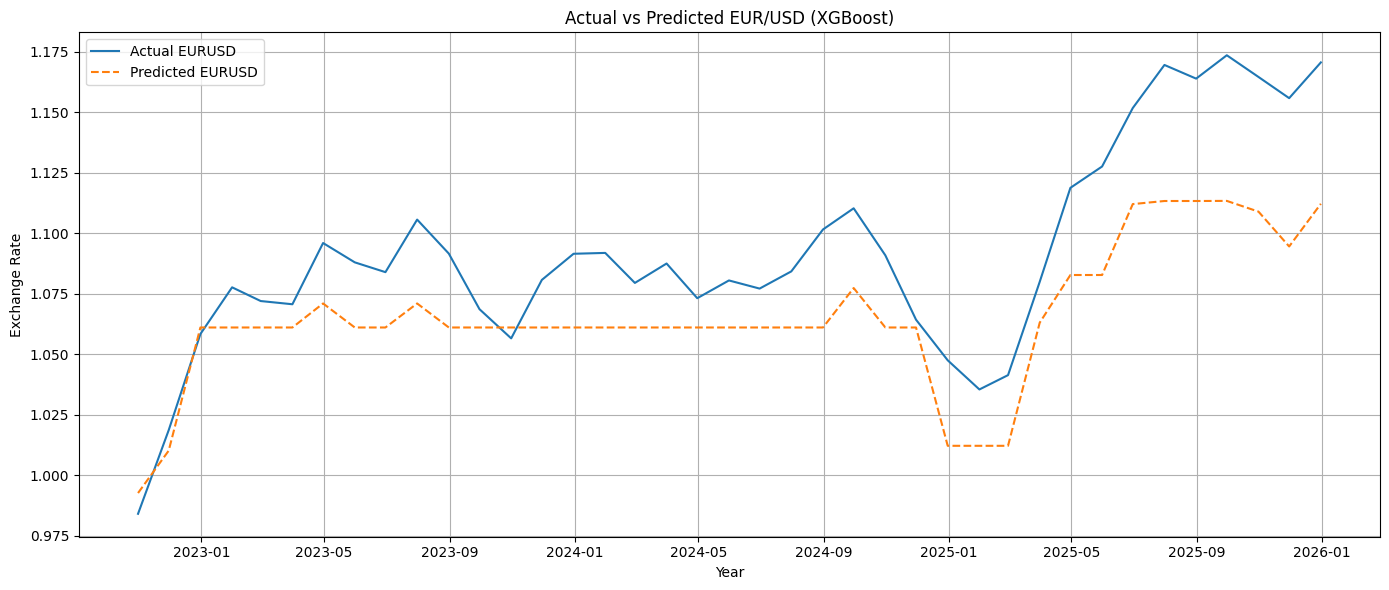

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(master_monthly["Date"][train_size:], y_test, label="Actual EURUSD")
plt.plot(
    master_monthly["Date"][train_size:],
    xgb_predictions,
    label="Predicted EURUSD",
    linestyle="--"
)
plt.title("Actual vs Predicted EUR/USD (XGBoost)")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()